# Calculating statistical differences between segmentation accuracy metrics for different segmentation methods

### For this example specifically, I have calculated the difference in Fscore, Precision, Recall, and the aggregated Jaccard Index (AJI) for the default cellpose SAM model, xenium segmentation, and a custom trained cellpose SAM model, using my test images from the custom training as 'Ground Truth' labels

In [1]:
#loading data
import pandas as pd

#default metrics
default = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\cellpose training\Crops_Round2\Model Performance\Cross-Sectional\Default_CellposeSAM_metrics.csv")
default_cellpose = default.dropna()

#Xenium metrics
xen = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\cellpose training\Crops_Round2\Model Performance\Cross-Sectional\Xenium_Proprietary_metrics.csv")
xenium_proprietary = xen.dropna()

#custom trained model metrics
custom = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\cellpose training\Crops_Round2\Model Performance\Cross-Sectional\Mouse_Ear_Skin_V8_metrics.csv")
custom_cellpose = custom.dropna()

#proseg
proseg = pd.read_csv(r"D:\Dom\Psoriasis project\4th year data\cellpose training\Crops_Round2\Model Performance\Cross-Sectional\proseg_metrics.csv")
proseg = proseg.dropna()

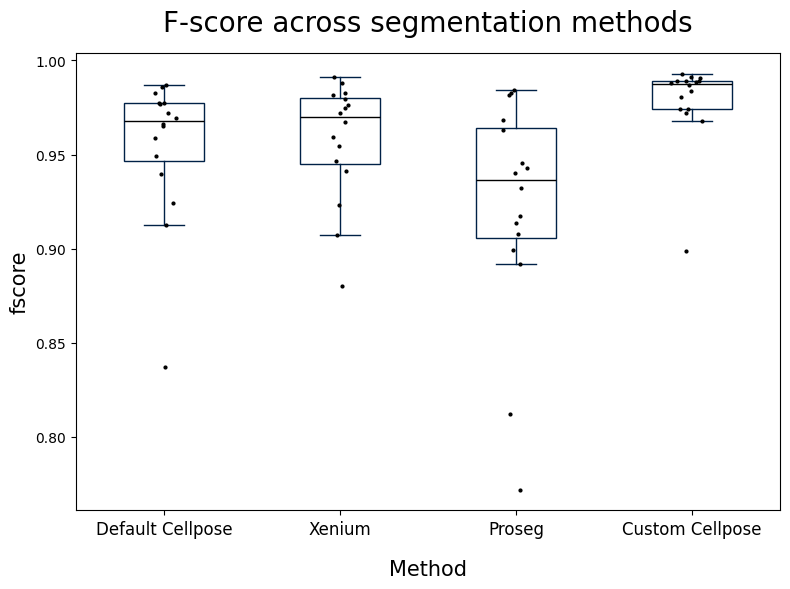

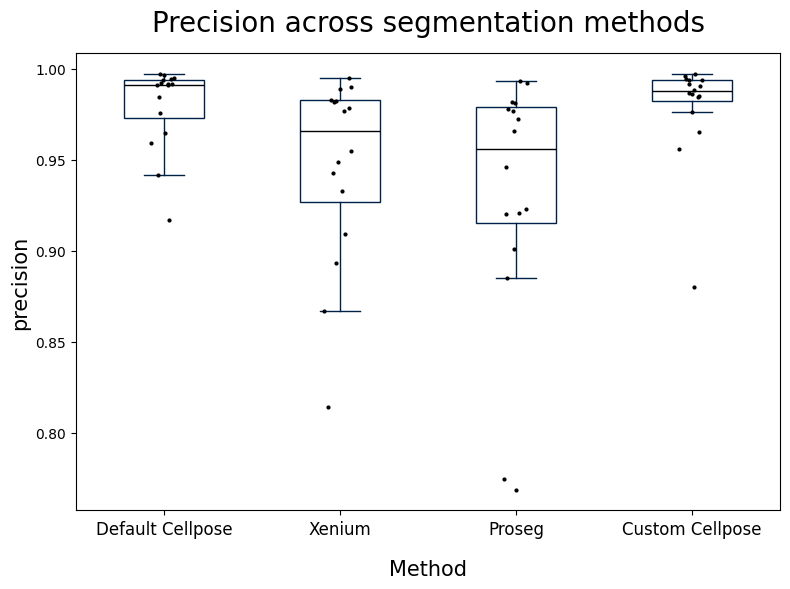

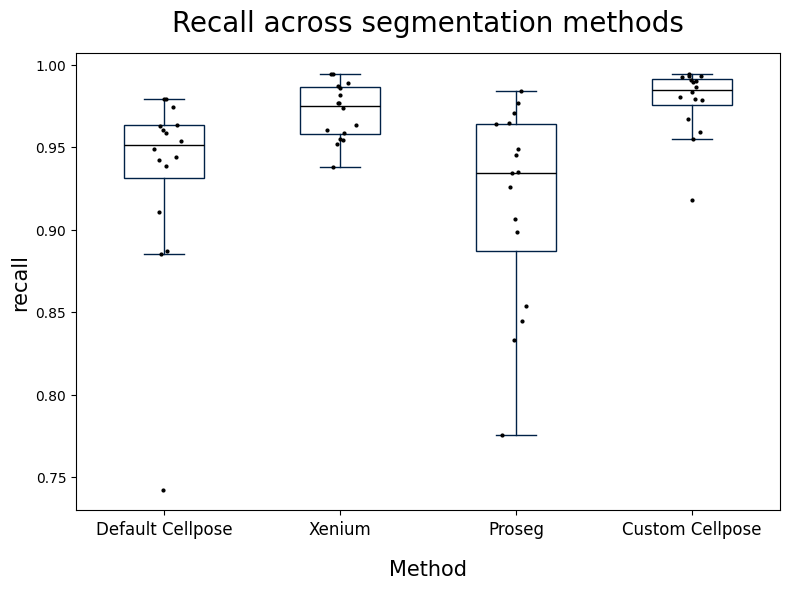

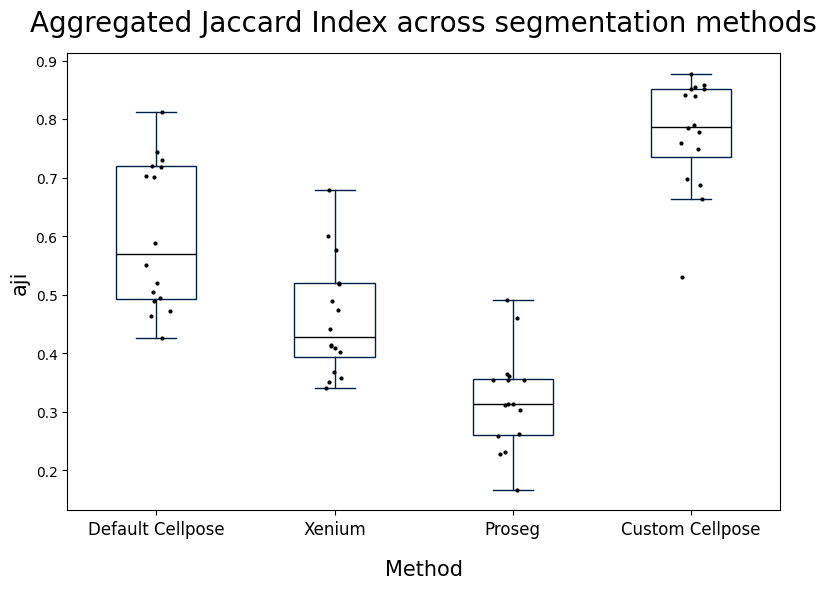

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_stats(metric_choice, segmentation_methods, title):
    """ 
    Plot boxplots comparing a metric of choice among several segmentation methods.

    *inputs*
    metric_choice = one of ["precision", "recall", "fscore", "aji"]
    segmentation_methods = {'method_name': dataframe} dict of dataframes containing given metric values for each image in the test set
    """
    data = [method[metric_choice] for method in segmentation_methods.values()]
    n = len(segmentation_methods)

    colors = ["#002147"] * n
    linewidth = 1

    fig, ax = plt.subplots(figsize=(8, 6))

    bp = ax.boxplot(data, tick_labels=list(segmentation_methods.keys()), showfliers=False, patch_artist=True)

    # Colour each box
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor('None')
        patch.set_edgecolor(color)
        patch.set_alpha(1)
        patch.set_linewidth(linewidth)

    # Colour the whiskers and caps to match
    for i, color in enumerate(colors):
        bp['whiskers'][i*2].set_color(color)
        bp['whiskers'][i*2+1].set_color(color)
        bp['whiskers'][i*2].set_linewidth(linewidth)
        bp['whiskers'][i*2+1].set_linewidth(linewidth)
        bp['caps'][i*2].set_color(color)
        bp['caps'][i*2+1].set_color(color)
        bp['caps'][i*2].set_linewidth(linewidth)
        bp['caps'][i*2+1].set_linewidth(linewidth)

    # Colour median lines
    for median in bp['medians']:
        median.set_color('black')

    # Overlay individual points with jitter
    for i, group in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(group))
        ax.plot(x, group, 'k.', alpha=1, markersize=4)

    ax.tick_params(axis='x', labelsize=12)

    ax.set_title(f"{title} across segmentation methods", fontsize = 20, y = 1.03)
    ax.set_xlabel("Method", fontsize = 15, labelpad=15)
    ax.set_ylabel(f"{metric_choice}", fontsize = 15)

    plt.tight_layout()
    plt.show()


plot_metric_stats('fscore',     {'Default Cellpose': default_cellpose, 'Xenium': xenium_proprietary, 'Proseg': proseg, 'Custom Cellpose': custom_cellpose}, title = 'F-score')
plot_metric_stats('precision',  {'Default Cellpose': default_cellpose, 'Xenium': xenium_proprietary, 'Proseg': proseg, 'Custom Cellpose': custom_cellpose}, title = 'Precision')
plot_metric_stats('recall',     {'Default Cellpose': default_cellpose, 'Xenium': xenium_proprietary, 'Proseg': proseg, 'Custom Cellpose': custom_cellpose}, title = 'Recall')
plot_metric_stats('aji',        {'Default Cellpose': default_cellpose, 'Xenium': xenium_proprietary, 'Proseg': proseg, 'Custom Cellpose': custom_cellpose}, title = 'Aggregated Jaccard Index')

### Add in significance on the graph
#### I have used a two-sample t-test in this case, as I only wish to compare the significance between the Xenium and Custom Trained models, thus am not carrying out multiple comparisons. Additionally, if i did wish to compare all methods, ANOVA would not be suitable as the within group variances are different for each group. 

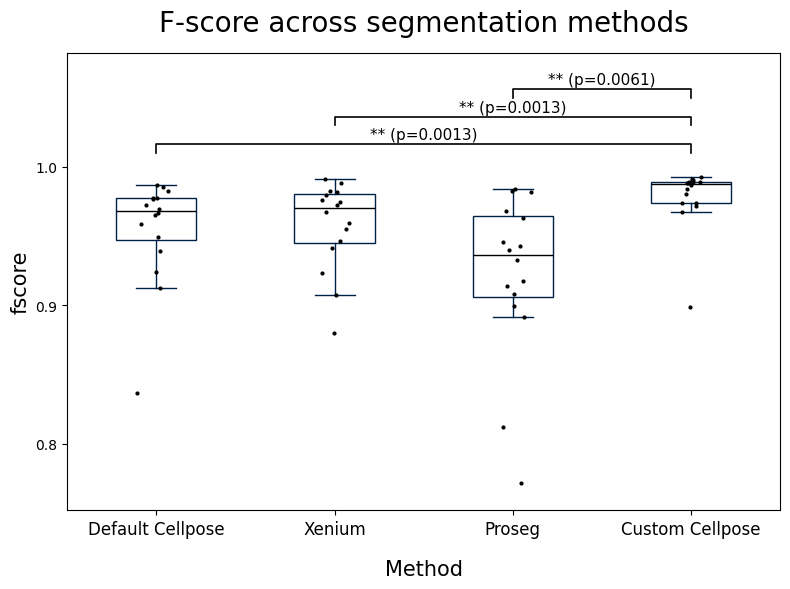

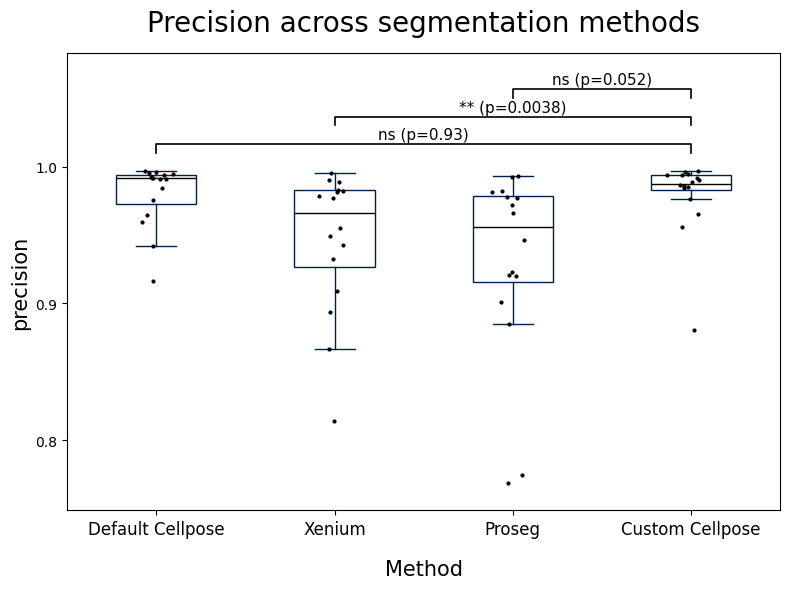

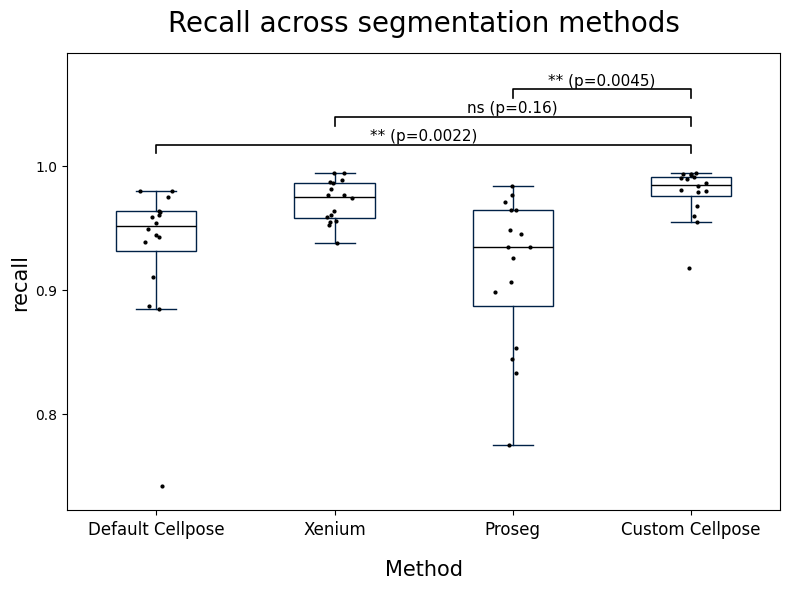

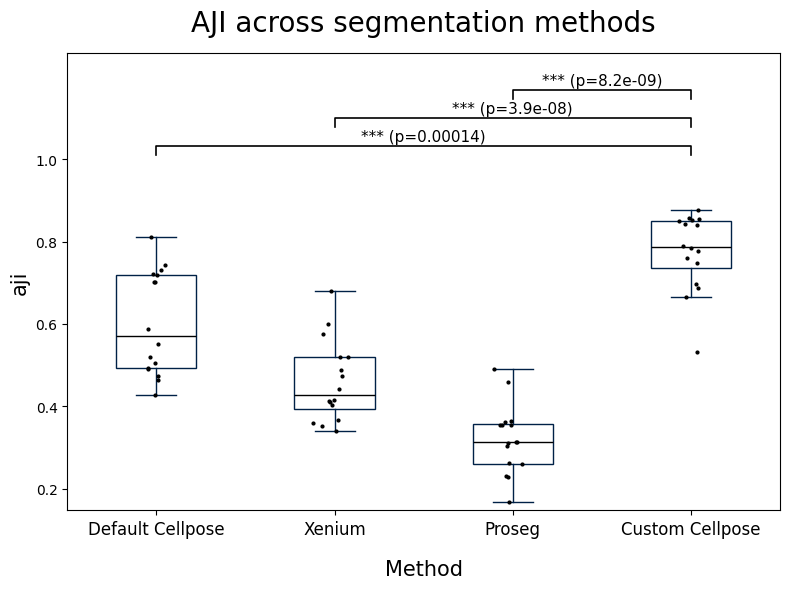

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

def get_significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

def add_significance_brace(ax, x1, x2, y, h, text, text_pad):
    # Draws the bracket geometry
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    # Places text compactly right above the horizontal crossbar
    ax.text((x1+x2)/2, y + h + text_pad, text, ha='center', va='bottom', fontsize=11)

def plot_metric_stats_sig(metric_choice, segmentation_methods, title, control_method='Custom Cellpose', show_ns=True):
    """
    Plot boxplots with targeted t-tests corrected for multiple comparisons (BH).
    Y-axis ticks are strictly capped at 1.0, while braces sit cleanly in the top margin.
    """
    data = [method[metric_choice] for method in segmentation_methods.values()]
    method_names = list(segmentation_methods.keys())
    n = len(method_names)

    colors = ["#002147"] * n
    linewidth = 1

    fig, ax = plt.subplots(figsize=(8, 6))

    bp = ax.boxplot(data, tick_labels=method_names, showfliers=False, patch_artist=True)

    # Colour formatting
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor('None')
        patch.set_edgecolor(color)
        patch.set_alpha(1)
        patch.set_linewidth(linewidth)

    for i, color in enumerate(colors):
        bp['whiskers'][i*2].set_color(color)
        bp['whiskers'][i*2+1].set_color(color)
        bp['whiskers'][i*2].set_linewidth(linewidth)
        bp['whiskers'][i*2+1].set_linewidth(linewidth)
        bp['caps'][i*2].set_color(color)
        bp['caps'][i*2+1].set_color(color)
        bp['caps'][i*2].set_linewidth(linewidth)
        bp['caps'][i*2+1].set_linewidth(linewidth)

    for median in bp['medians']:
        median.set_color('black')

    # Data points with jitter
    for i, group in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(group))
        ax.plot(x, group, 'k.', alpha=1, markersize=4)

    # --- 1. Dynamic Y-Axis Scaling & Strict 1.0 Tick Cap ---
    all_values = np.concatenate([np.array(group) for group in data])
    min_val = np.min(all_values)
    
    # Scale y-axis view to start 2% below the lowest individual data point
    y_min = max(0.0, min_val - 0.02)
    span = 1.0 - y_min

    # Select an elegant tick interval based on how zoomed-in the variance is
    if span > 0.5:
        step = 0.2
    elif span > 0.2:
        step = 0.1
    elif span > 0.06:
        step = 0.02
    else:
        step = 0.01
        
    start_tick = np.ceil(y_min / step) * step
    ticks = np.arange(start_tick, 1.001, step)
    ax.set_yticks(ticks) # Force ticks to strictly obey the 1.0 mathematical limit

    # --- 2. Targeted T-Tests (Comparison to Control) ---
    if control_method not in method_names:
        raise ValueError(f"Control method '{control_method}' not found.")
    
    control_idx = method_names.index(control_method)
    
    pairs_indices = []
    for i in range(n):
        if i != control_idx:
            pairs_indices.append((i, control_idx))

    raw_pvals = [stats.ttest_rel(data[i], data[j]).pvalue for i, j in pairs_indices]
    _, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

    # --- 3. Micro-Adjusted Significance Braces ---
    # Scaled gracefully relative to the window profile, but kept highly compact
    brace_h = span * 0.025    # Shortened downbracket leg length
    text_pad = span * 0.005   # Tighter space between horizontal line and text
    brace_gap = span * 0.05   # Compact stepping distance between stacked bars

    # Braces originate just clear of the 1.0 line boundary
    y_current = 1.01 

    for level, ((i, j), p_corr) in enumerate(zip(pairs_indices, corrected_pvals)):
        label = get_significance_label(p_corr)
        if label == 'ns' and not show_ns:
            continue
            
        x1, x2 = i + 1, j + 1
        # Combined onto a single horizontal line string to avoid vertical text clutter
        text_str = f"{label} (p={p_corr:.2g})"
        
        add_significance_brace(ax, x1, x2, y_current, brace_h, text_str, text_pad)
        
        # Advance baseline forward to clear the current drawn element layout
        y_current += brace_h + text_pad + brace_gap

    # Expand the plot container limit to accommodate text overhead in clean white space
    ax.set_ylim(y_min, y_current + brace_gap)

    ax.tick_params(axis='x', labelsize=12)
    ax.set_title(f"{title} across segmentation methods", fontsize=20, y=1.03)
    ax.set_xlabel("Method", fontsize=15, labelpad=15)
    ax.set_ylabel(f"{metric_choice}", fontsize=15)

    plt.tight_layout()
    plt.show()

plot_metric_stats_sig('fscore',    {'Default Cellpose': default_cellpose, 'Xenium': xenium_proprietary, 'Proseg': proseg, 'Custom Cellpose': custom_cellpose}, title='F-score')
plot_metric_stats_sig('precision', {'Default Cellpose': default_cellpose, 'Xenium': xenium_proprietary, 'Proseg': proseg, 'Custom Cellpose': custom_cellpose}, title='Precision')
plot_metric_stats_sig('recall',    {'Default Cellpose': default_cellpose, 'Xenium': xenium_proprietary, 'Proseg': proseg, 'Custom Cellpose': custom_cellpose}, title='Recall')
plot_metric_stats_sig('aji',       {'Default Cellpose': default_cellpose, 'Xenium': xenium_proprietary, 'Proseg': proseg, 'Custom Cellpose': custom_cellpose}, title='AJI')